## 0. 목적과 분석 설계

본 노트북의 목적:
- `data_0514_1800_v2/` 데이터셋에 대해 **allow vs anomaly(=block)** 행동 차이를 정량적으로 확인.
- type(BOOKING / CAPTCHA / DETAIL) 간 **정상(allow) 행동 분포 차이**를 분석.
- **Isolation Forest** 세 전략(pooled_global / pooled_type_threshold / type_specific)을 비교하여 운영 모델 후보를 선정.

노트북 구성:
1. Data Loading
2. Data Overview
3. Feature Selection & Missing Rate
4. SMD — allow vs anomaly
5. Allow-only Type Difference
6. Feature Distribution
7. PCA + Optional UMAP
8. Isolation Forest 전략 비교
9. Final Auto Summary

제약:
- 본 노트북은 결과를 **셀 출력으로만** 관리한다. 파일(csv/png/md/json/pkl/joblib/py 등) 산출 금지.
- `eda_chan.ipynb` 의 df 를 참조하지 않고, `data_0514_1800_v2/**/*.json` 을 새로 로딩하여 `df_eda` 를 구성한다.
- 경로 segment 기준으로 `type` / `label_norm` 을 부여 (JSON 내부 `type` 필드보다 경로 우선).
- 원본 JSON 은 read-only.

In [1]:
from __future__ import annotations

import json
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Korean font (platform-aware)
_system = platform.system()
if _system == 'Darwin':
    _font_candidates = ['Nanum Gothic', 'AppleGothic']
elif _system == 'Windows':
    _font_candidates = ['Malgun Gothic']
else:
    _font_candidates = ['NanumGothic', 'Nanum Gothic', 'DejaVu Sans']
for _fn in _font_candidates:
    try:
        mpl.rcParams['font.family'] = _fn
        break
    except Exception:
        continue
mpl.rcParams['axes.unicode_minus'] = False

# pandas display
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 220)

# seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# data_0514_1800_v2 경로 자동 탐색
_nb = Path.cwd()
_cands = [
    _nb / '../../data/data_0514_1800_v2',
    _nb / '../data/data_0514_1800_v2',
    _nb / '../../../data/data_0514_1800_v2',
    Path('services/ai/data/data_0514_1800_v2'),
]
DATA_DIR = None
for _c in _cands:
    if _c.exists():
        DATA_DIR = _c.resolve()
        break
assert DATA_DIR is not None and DATA_DIR.exists(), f'data_0514_1800_v2 폴더를 찾지 못했습니다. CWD={_nb}'
print('DATA_DIR =', DATA_DIR)

DATA_DIR = C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_0514_1800_v2


## 1. Data Loading

`data_0514_1800_v2/` 하위의 `trial_*.json` 을 모두 재귀 탐색하여 `df_eda` 를 생성한다.
- nested dict 은 `pandas.json_normalize` 로 flatten (`metrics.*` 등).
- 경로 segment 로부터 `type` / `label_norm` 컬럼을 부여.

In [2]:
PATH_TYPE_MAP = {'booking': 'BOOKING', 'captcha': 'CAPTCHA', 'detail': 'DETAIL'}
PATH_LABEL_MAP = {'allow': 'allow', 'block': 'anomaly'}
TYPES = ['BOOKING', 'CAPTCHA', 'DETAIL']
LABELS = ['allow', 'anomaly']

def _resolve_type_label(p: Path):
    parts = {s.lower() for s in p.parts}
    t = next((PATH_TYPE_MAP[k] for k in PATH_TYPE_MAP if k in parts), None)
    l = next((PATH_LABEL_MAP[k] for k in PATH_LABEL_MAP if k in parts), None)
    return t, l

def load_df_eda(base: Path) -> pd.DataFrame:
    files = sorted(base.rglob('trial_*.json'))
    rows = []
    skipped = []
    for p in files:
        try:
            with open(p, 'r', encoding='utf-8') as f:
                obj = json.load(f)
        except Exception as e:
            skipped.append((str(p), repr(e)))
            continue
        t, l = _resolve_type_label(p)
        if t is None or l is None:
            skipped.append((str(p), 'path segment mismatch'))
            continue
        flat = pd.json_normalize(obj, sep='.')
        flat['source_path'] = str(p)
        flat['source_file'] = p.name
        flat['type'] = t
        flat['label_norm'] = l
        rows.append(flat)
    if not rows:
        raise RuntimeError('로딩된 trial JSON 이 없습니다.')
    df = pd.concat(rows, ignore_index=True, sort=False)
    if skipped:
        print(f'[WARN] skipped {len(skipped)} files')
        for s in skipped[:5]:
            print('  ', s)
    return df, len(files)

df_eda, _n_files = load_df_eda(DATA_DIR)
print(f'JSON files discovered: {_n_files}')
print(f'df_eda.shape         : {df_eda.shape}')
print('columns:')
for _c in df_eda.columns.tolist():
    print(f'  {_c}')
print()
print('=== label_norm × type count ===')
print(pd.crosstab(df_eda['label_norm'], df_eda['type'], margins=True, margins_name='ALL'))

JSON files discovered: 707
df_eda.shape         : (707, 40)
columns:
  trialId
  label
  type
  metrics.reclick_rate
  metrics.misclick_rate
  metrics.mouse_jerk_mean
  metrics.double_click_rate
  metrics.mouse_overshoot_flag
  metrics.mousemove_event_rate
  metrics.pre_click_scroll_flag
  metrics.time_to_first_click_ms
  metrics.inter_click_interval_ms
  metrics.mouse_acceleration_mean
  metrics.mouse_speed_change_mean
  metrics.pre_click_hover_time_ms
  metrics.click_offset_variance_px
  metrics.mouse_stop_segment_count
  metrics.mouse_avg_speed_px_per_ms
  metrics.mouse_hover_dwell_time_ms
  metrics.mouse_max_speed_px_per_ms
  metrics.mouse_path_curvature_mean
  metrics.pre_click_mousemove_count
  metrics.click_position_repeat_rate
  metrics.mouse_direction_change_count
  metrics.mouse_path_straightness_score
  metrics.edge_or_fixed_point_visit_rate
  metrics.mouse_total_travel_distance_px
  metrics.click_sequence_consistency_score
  metrics.immediate_post_render_click_rate
  metric

## 2. Data Overview

=== label_norm × type count pivot ===
type        BOOKING  CAPTCHA  DETAIL  ALL
label_norm                               
allow            64       87      93  244
anomaly         148      151     164  463
ALL             212      238     257  707

=== label_norm × type ratio (전체 합 = 1) ===
type        BOOKING  CAPTCHA  DETAIL
label_norm                          
allow        0.0905   0.1231  0.1315
anomaly      0.2093   0.2136  0.2320



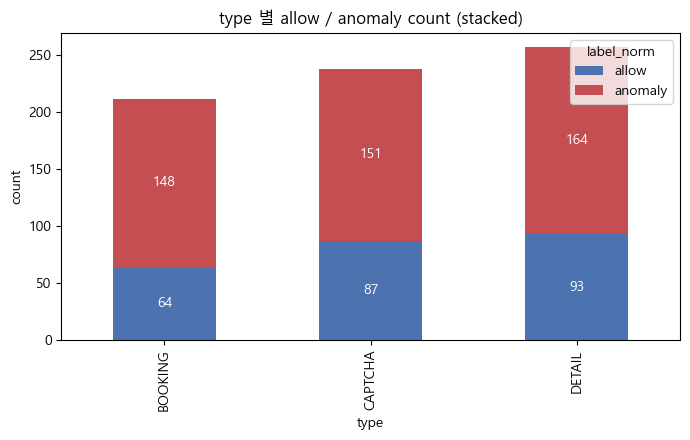

In [3]:
# 1) count pivot
count_pivot = pd.crosstab(df_eda['label_norm'], df_eda['type'], margins=True, margins_name='ALL')
print('=== label_norm × type count pivot ===')
print(count_pivot)
print()

# 2) ratio table (전체 합 = 1)
_total = len(df_eda)
ratio_pivot = (pd.crosstab(df_eda['label_norm'], df_eda['type']) / _total).round(4)
print('=== label_norm × type ratio (전체 합 = 1) ===')
print(ratio_pivot)
print()

# 3) stacked bar
ct = pd.crosstab(df_eda['type'], df_eda['label_norm'])
_label_color = {'allow': '#4C72B0', 'anomaly': '#C44E52'}
fig, ax = plt.subplots(figsize=(7, 4.5))
ct.plot(kind='bar', stacked=True, ax=ax,
        color=[_label_color.get(c, '#888888') for c in ct.columns])
ax.set_title('type 별 allow / anomaly count (stacked)')
ax.set_xlabel('type'); ax.set_ylabel('count')
for i, tname in enumerate(ct.index):
    cum = 0
    for lab in ct.columns:
        v = int(ct.loc[tname, lab])
        if v > 0:
            ax.text(i, cum + v / 2, str(v), ha='center', va='center',
                    color='white', fontsize=10)
            cum += v
ax.legend(title='label_norm')
plt.tight_layout(); plt.show()

# 4) sanity warnings
WARN_MIN_ANOMALY = 30
for t in TYPES:
    sub = df_eda[df_eda['type'] == t]
    n_allow = int((sub['label_norm'] == 'allow').sum())
    n_anom = int((sub['label_norm'] == 'anomaly').sum())
    if n_allow == 0:
        print(f'[WARN] type={t} 에 allow 데이터가 없습니다.')
    if n_anom == 0:
        print(f'[WARN] type={t} 에 anomaly 데이터가 없습니다.')
    if 0 < n_anom < WARN_MIN_ANOMALY:
        print(f'[WARN] type={t} anomaly 수 {n_anom} < {WARN_MIN_ANOMALY} — SMD/IF 신뢰도 낮음.')

## 3. Feature Selection & Missing Rate

숫자형 컬럼만 feature 후보로 사용. 메타/식별자 계열은 제외.

high-risk 기준:
- overall missing rate ≥ 0.3, 또는
- group 간 missing rate 차이 ≥ 0.3, 또는
- 특정 group 에서 missing rate ≥ 0.8

In [4]:
EXCLUDE_EXACT = {'label_norm', 'type', 'source_path', 'source_file',
                 'id', 'trial_id', 'trialId', 'user_id', 'session_id',
                 'timestamp', 'label'}
EXCLUDE_SUBSTR = ['session_id', 'timestamp', 'trial_id', 'trialId', 'user_id']

numeric_all = df_eda.select_dtypes(include=[np.number]).columns.tolist()

def _excluded(col: str) -> bool:
    if col in EXCLUDE_EXACT:
        return True
    return any(sub in col for sub in EXCLUDE_SUBSTR)

FEATURE_CANDIDATES = [c for c in numeric_all if not _excluded(c)]
print(f'numeric columns total          : {len(numeric_all)}')
print(f'feature candidates after excl  : {len(FEATURE_CANDIDATES)}')
print()

# 1) overall missing
miss_overall = (df_eda[FEATURE_CANDIDATES].isna().mean()
                .sort_values(ascending=False).rename('missing_rate'))
print('=== overall missing rate (desc) ===')
print(miss_overall.to_frame().head(40))
print()

# 2) by label_norm
miss_by_label = (df_eda.groupby('label_norm')[FEATURE_CANDIDATES]
                 .apply(lambda g: g.isna().mean()).T)
print('=== missing rate by label_norm ===')
print(miss_by_label.head(40))
print()

# 3) by type
miss_by_type = (df_eda.groupby('type')[FEATURE_CANDIDATES]
                .apply(lambda g: g.isna().mean()).T)
print('=== missing rate by type ===')
print(miss_by_type.head(40))
print()

# 4) by (label_norm, type)
miss_by_lt = (df_eda.groupby(['label_norm', 'type'])[FEATURE_CANDIDATES]
              .apply(lambda g: g.isna().mean()).T)
print('=== missing rate by (label_norm, type) ===')
print(miss_by_lt.head(40))
print()

# high-risk
group_max = miss_by_lt.max(axis=1)
group_diff = miss_by_lt.max(axis=1) - miss_by_lt.min(axis=1)

def _risk_reason(f):
    rs = []
    if miss_overall[f] >= 0.3:
        rs.append(f'overall={miss_overall[f]:.2f}')
    if group_diff[f] >= 0.3:
        rs.append(f'group_diff={group_diff[f]:.2f}')
    if group_max[f] >= 0.8:
        rs.append(f'group_max={group_max[f]:.2f}')
    return '; '.join(rs)

HIGH_RISK_MISSING_FEATURES = [
    f for f in FEATURE_CANDIDATES
    if miss_overall[f] >= 0.3 or group_diff[f] >= 0.3 or group_max[f] >= 0.8
]
hr_df = pd.DataFrame({
    'overall_missing': miss_overall.reindex(HIGH_RISK_MISSING_FEATURES),
    'group_max_missing': group_max.reindex(HIGH_RISK_MISSING_FEATURES),
    'group_diff_missing': group_diff.reindex(HIGH_RISK_MISSING_FEATURES),
    'reason': [_risk_reason(f) for f in HIGH_RISK_MISSING_FEATURES],
}).sort_values('overall_missing', ascending=False)
print(f'=== HIGH-RISK missing features (n={len(HIGH_RISK_MISSING_FEATURES)}) ===')
print(hr_df)

FEATURES_USED = [f for f in FEATURE_CANDIDATES if f not in HIGH_RISK_MISSING_FEATURES]
print(f'\nFEATURES_USED (after dropping high-risk): {len(FEATURES_USED)}')

numeric columns total          : 33
feature candidates after excl  : 32

=== overall missing rate (desc) ===
                                                 missing_rate
metrics.mouse_jerk_mean                              0.428571
metrics.inter_element_move_interval_std_ms           0.420085
metrics.click_offset_variance_px                     0.417256
metrics.inter_click_interval_ms                      0.326733
metrics.mouse_acceleration_mean                      0.216407
metrics.mouse_speed_change_mean                      0.216407
metrics.mouse_avg_speed_px_per_ms                    0.216407
metrics.mouse_max_speed_px_per_ms                    0.216407
metrics.mouse_path_straightness_score                0.216407
metrics.mouse_total_travel_distance_px               0.216407
metrics.mouse_path_curvature_mean                    0.216407
metrics.edge_or_fixed_point_visit_rate               0.216407
metrics.mouse_hover_dwell_time_ms                    0.216407
metrics.time_to_first_c

## 4. SMD — allow vs anomaly

SMD = (mean_allow − mean_anomaly) / pooled_std,  pooled_std = sqrt((var_allow + var_anomaly) / 2)
- pooled_std = 0 → NaN
- 결측은 group 별 dropna 후 계산
- |SMD| 기준 정렬

In [5]:
SMD_LEVELS = [
    (0.0, 0.1, 'negligible', '#BDBDBD'),
    (0.1, 0.2, 'small',      '#A1C9F4'),
    (0.2, 0.5, 'medium',     '#FFB482'),
    (0.5, 0.8, 'large',      '#FF9F9B'),
    (0.8, 1.2, 'very_large', '#D0BBFF'),
    (1.2, np.inf, 'huge',    '#8DE5A1'),
]

def smd_level(s):
    a = abs(s)
    if not np.isfinite(a):
        return 'nan'
    for lo, hi, name, _ in SMD_LEVELS:
        if lo <= a < hi:
            return name
    return 'huge'

def smd_color(s):
    a = abs(s)
    if not np.isfinite(a):
        return '#FFFFFF'
    for lo, hi, _, c in SMD_LEVELS:
        if lo <= a < hi:
            return c
    return SMD_LEVELS[-1][3]

def compute_smd(df, features, group_col, pos, neg):
    rows = []
    for f in features:
        a = df.loc[df[group_col] == pos, f].dropna()
        b = df.loc[df[group_col] == neg, f].dropna()
        if len(a) < 2 or len(b) < 2:
            rows.append((f, np.nan, len(a), len(b), np.nan, np.nan))
            continue
        m1, m2 = a.mean(), b.mean()
        v1, v2 = a.var(ddof=1), b.var(ddof=1)
        pooled = np.sqrt((v1 + v2) / 2.0)
        smd = (m1 - m2) / pooled if pooled > 0 else np.nan
        rows.append((f, smd, len(a), len(b), m1, m2))
    out = pd.DataFrame(rows, columns=['feature', 'SMD', f'n_{pos}', f'n_{neg}',
                                       f'mean_{pos}', f'mean_{neg}'])
    out['abs_SMD'] = out['SMD'].abs()
    out['level'] = out['SMD'].apply(smd_level)
    return out.sort_values('abs_SMD', ascending=False, na_position='last').reset_index(drop=True)

smd_overall = compute_smd(df_eda, FEATURE_CANDIDATES, 'label_norm', 'allow', 'anomaly')
print('=== SMD top 20 (overall, allow vs anomaly) ===')
print(smd_overall.head(20).to_string(index=False))
print()

smd_by_type = {}
for t in TYPES:
    sub = df_eda[df_eda['type'] == t]
    smd_by_type[t] = compute_smd(sub, FEATURE_CANDIDATES, 'label_norm', 'allow', 'anomaly')
    print(f'=== SMD top 15 — {t} ===')
    print(smd_by_type[t].head(15).to_string(index=False))
    print()

# feature × type abs_SMD pivot
pivot_abs = pd.DataFrame({t: smd_by_type[t].set_index('feature')['abs_SMD'] for t in TYPES})
pivot_abs['OVERALL'] = smd_overall.set_index('feature')['abs_SMD']
pivot_abs = pivot_abs.reindex(smd_overall['feature']).round(3)
print('=== feature × type abs_SMD pivot (sorted by OVERALL) ===')
print(pivot_abs.head(30))

=== SMD top 20 (overall, allow vs anomaly) ===
                                        feature       SMD  n_allow  n_anomaly   mean_allow  mean_anomaly  abs_SMD      level
                   metrics.mousemove_event_rate  2.298373      244        463     8.639773      1.640944 2.298373       huge
              metrics.pre_click_mousemove_count  2.258232      244        463     5.176260      1.626098 2.258232       huge
      metrics.pre_click_path_300ms_straightness  2.047340      244        463     0.698402      0.025832 2.047340       huge
              metrics.mouse_path_curvature_mean  1.685479      240        314     0.107517      0.025532 1.685479       huge
                      metrics.double_click_rate -1.126201      244        463     0.129850      0.459352 1.126201 very_large
               metrics.click_offset_variance_px -0.951586      113        299   188.273972    801.282245 0.951586 very_large
                metrics.mouse_acceleration_mean  0.931642      240        314 

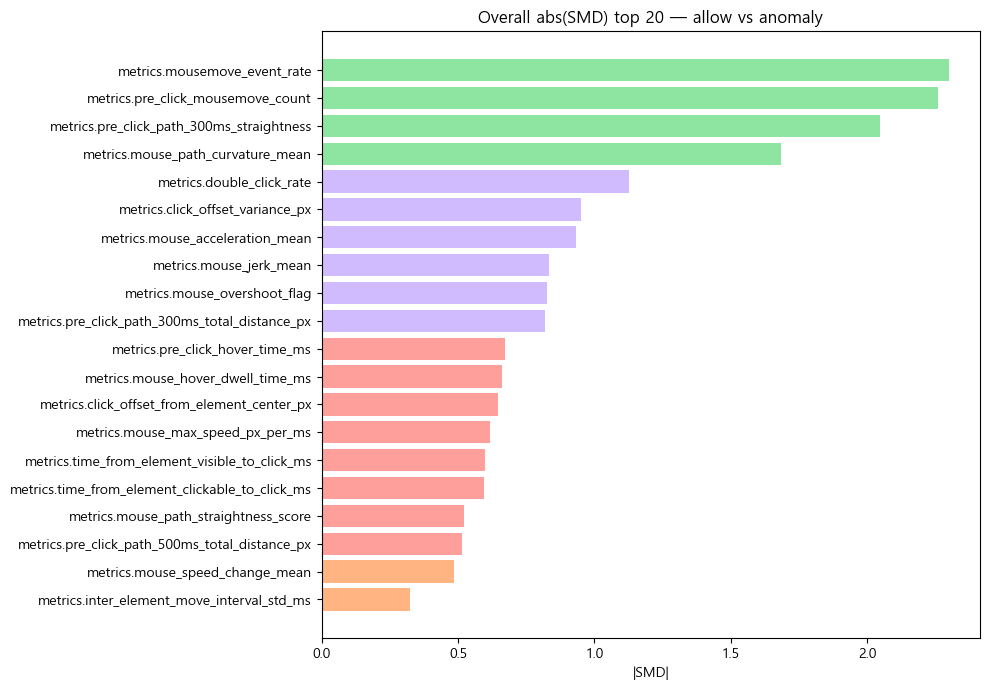

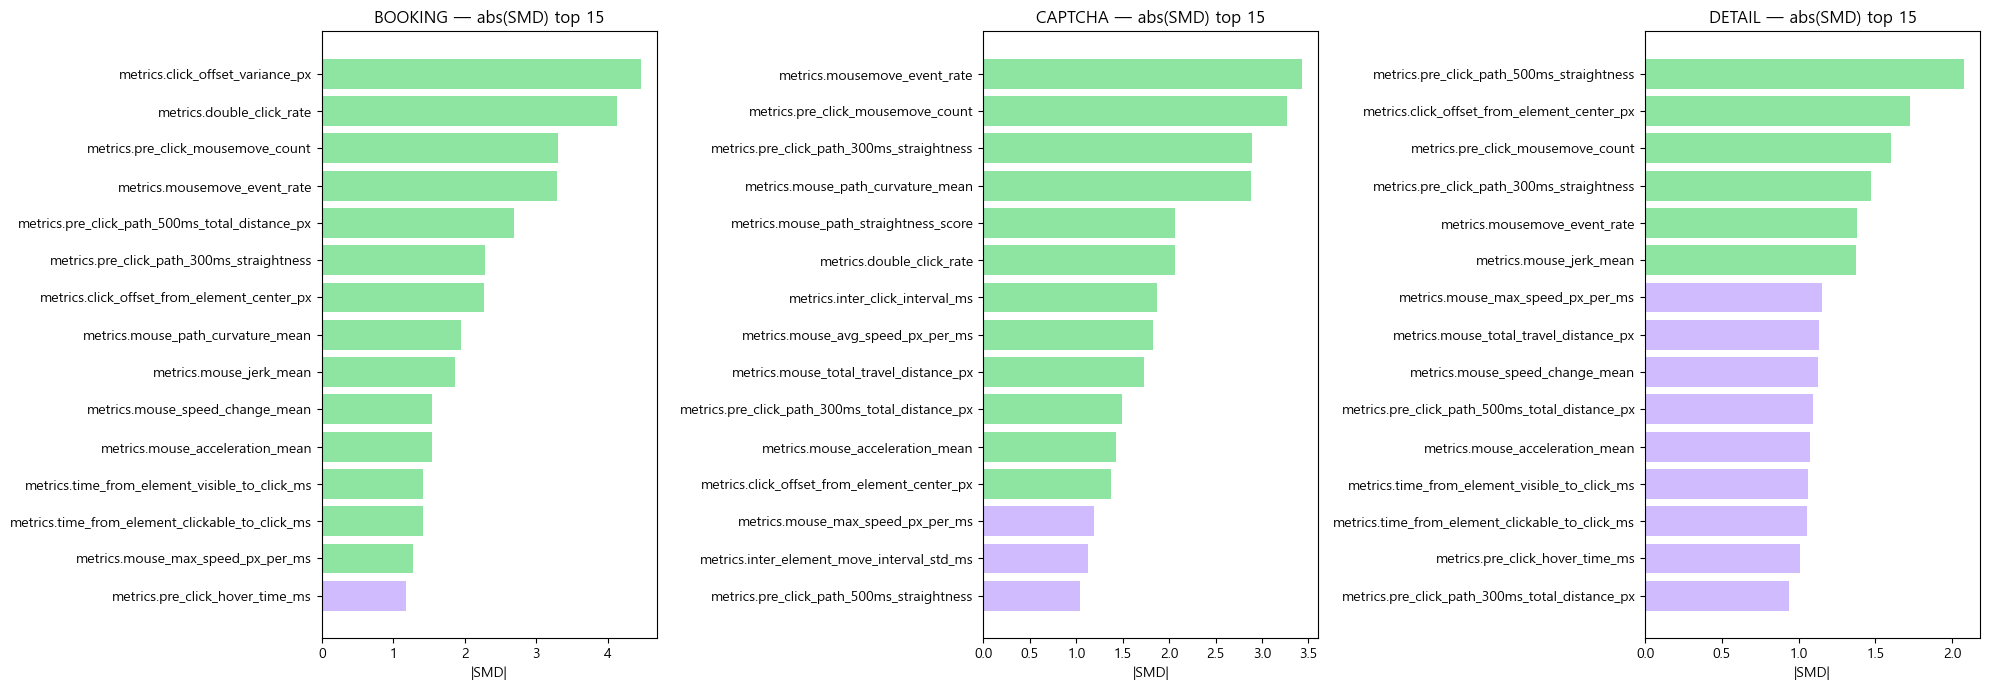

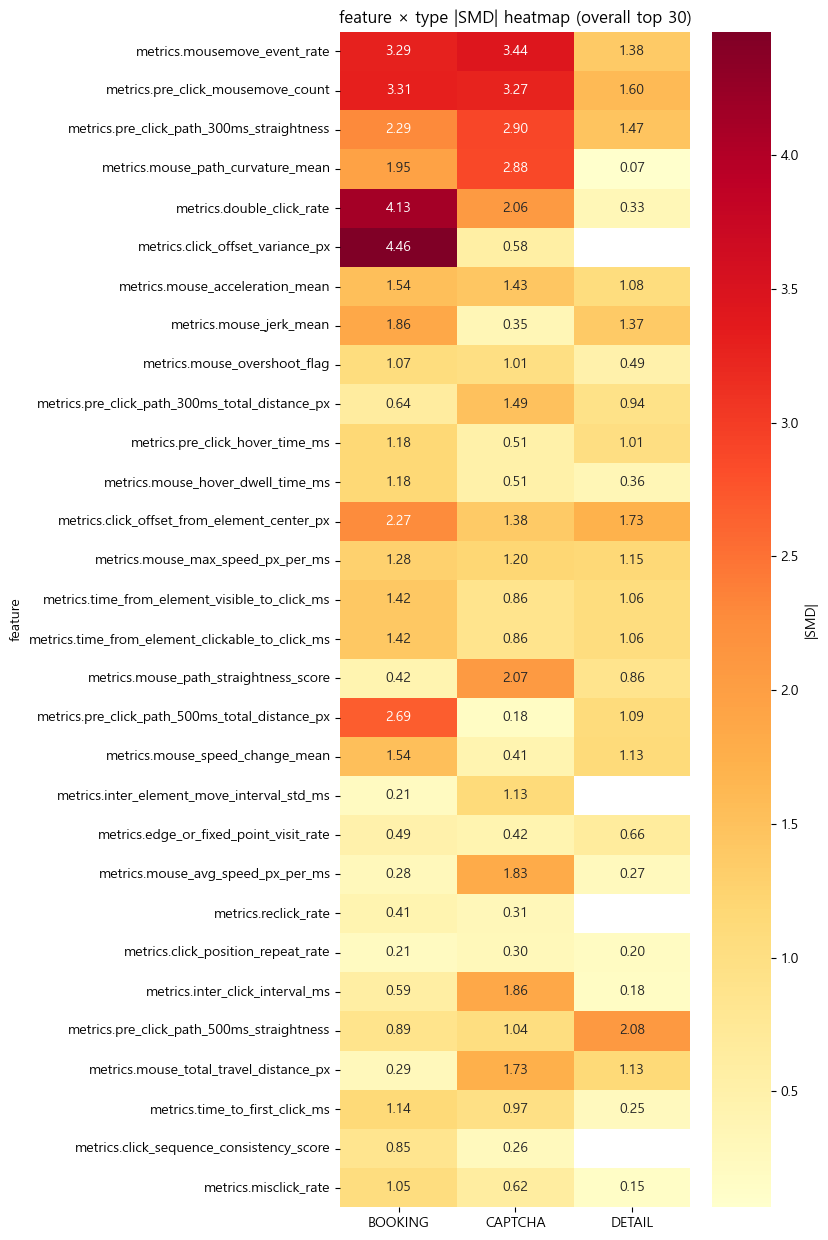

In [6]:
# overall top 20 barplot
top20 = smd_overall.dropna(subset=['SMD']).head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['feature'], top20['abs_SMD'],
        color=[smd_color(s) for s in top20['SMD']])
ax.invert_yaxis()
ax.set_title('Overall abs(SMD) top 20 — allow vs anomaly')
ax.set_xlabel('|SMD|')
plt.tight_layout(); plt.show()

# per-type top 15 barplots (3 subplots)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, t in zip(axes, TYPES):
    top = smd_by_type[t].dropna(subset=['SMD']).head(15)
    ax.barh(top['feature'], top['abs_SMD'],
            color=[smd_color(s) for s in top['SMD']])
    ax.invert_yaxis()
    ax.set_title(f'{t} — abs(SMD) top 15')
    ax.set_xlabel('|SMD|')
plt.tight_layout(); plt.show()

# feature × type heatmap (overall top 30)
hm = pivot_abs.drop(columns=['OVERALL']).head(30)
fig, ax = plt.subplots(figsize=(8, 0.35 * len(hm) + 2))
sns.heatmap(hm, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '|SMD|'})
ax.set_title('feature × type |SMD| heatmap (overall top 30)')
plt.tight_layout(); plt.show()

## 5. Allow-only Type Difference

allow 데이터만 사용해 type(BOOKING/CAPTCHA/DETAIL) 간 정상 행동 분포 차이를 본다.
각 feature 의 모든 type 페어 SMD 중 max|SMD| 를 대표값으로 사용.

=== allow-only — type 간 max |SMD| top 20 ===
                                       feature  max_abs_SMD_signed               pair  max_abs_SMD
      metrics.click_sequence_consistency_score            2.375672  CAPTCHA_vs_DETAIL     2.375672
    metrics.inter_element_move_interval_std_ms            1.762158 BOOKING_vs_CAPTCHA     1.762158
   metrics.click_offset_from_element_center_px           -1.557386  BOOKING_vs_DETAIL     1.557386
             metrics.mouse_max_speed_px_per_ms            1.370940 BOOKING_vs_CAPTCHA     1.370940
        metrics.mouse_total_travel_distance_px            1.274328  BOOKING_vs_DETAIL     1.274328
             metrics.mouse_avg_speed_px_per_ms            1.223845 BOOKING_vs_CAPTCHA     1.223845
               metrics.mouse_acceleration_mean            1.188089 BOOKING_vs_CAPTCHA     1.188089
         metrics.mouse_path_straightness_score           -1.126500  CAPTCHA_vs_DETAIL     1.126500
             metrics.mouse_hover_dwell_time_ms           -1.0409

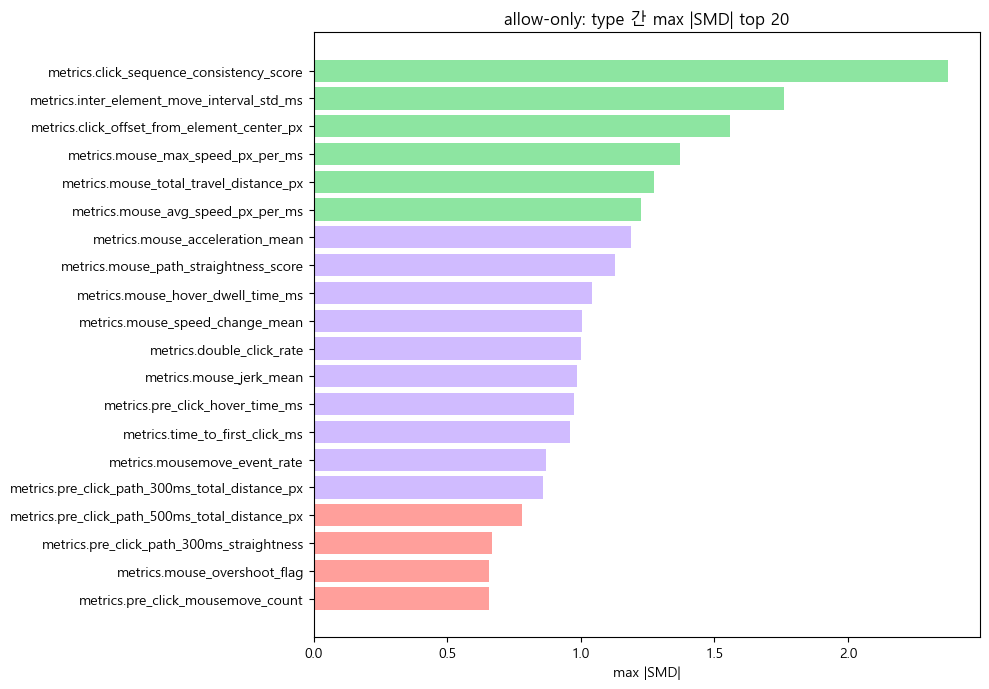

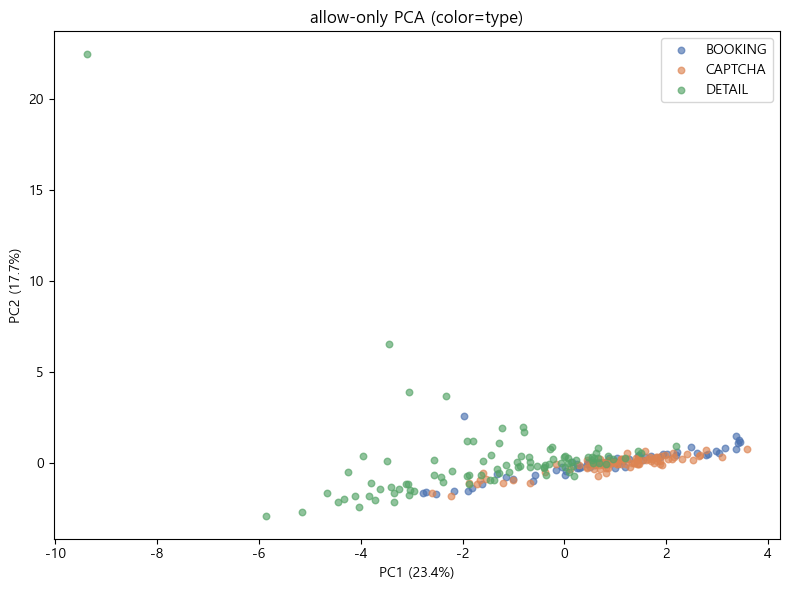

allow-only PCA cumulative EVR (PC1+PC2) = 0.4102


In [7]:
df_allow = df_eda[df_eda['label_norm'] == 'allow'].copy()

def pairwise_max_abs_smd(df, features, group_col, groups):
    rows = []
    for f in features:
        series = {g: df.loc[df[group_col] == g, f].dropna() for g in groups}
        cand = []
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                a, b = series[groups[i]], series[groups[j]]
                if len(a) < 2 or len(b) < 2:
                    continue
                v1, v2 = a.var(ddof=1), b.var(ddof=1)
                pooled = np.sqrt((v1 + v2) / 2.0)
                if pooled > 0:
                    cand.append(((a.mean() - b.mean()) / pooled,
                                 f'{groups[i]}_vs_{groups[j]}'))
        if not cand:
            rows.append((f, np.nan, ''))
            continue
        best = max(cand, key=lambda x: abs(x[0]))
        rows.append((f, best[0], best[1]))
    out = pd.DataFrame(rows, columns=['feature', 'max_abs_SMD_signed', 'pair'])
    out['max_abs_SMD'] = out['max_abs_SMD_signed'].abs()
    return out.sort_values('max_abs_SMD', ascending=False, na_position='last').reset_index(drop=True)

allow_type_smd = pairwise_max_abs_smd(df_allow, FEATURE_CANDIDATES, 'type', TYPES)
print('=== allow-only — type 간 max |SMD| top 20 ===')
print(allow_type_smd.head(20).to_string(index=False))

# top 20 barplot
top20a = allow_type_smd.dropna(subset=['max_abs_SMD']).head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20a['feature'], top20a['max_abs_SMD'],
        color=[smd_color(s) for s in top20a['max_abs_SMD_signed']])
ax.invert_yaxis()
ax.set_title('allow-only: type 간 max |SMD| top 20')
ax.set_xlabel('max |SMD|')
plt.tight_layout(); plt.show()

# allow-only PCA by type
_pipe_a = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=RANDOM_STATE)),
])
proj_a = _pipe_a.fit_transform(df_allow[FEATURES_USED].values)
evr_a = _pipe_a.named_steps['pca'].explained_variance_ratio_
_tc = {'BOOKING': '#4C72B0', 'CAPTCHA': '#DD8452', 'DETAIL': '#55A467'}
fig, ax = plt.subplots(figsize=(8, 6))
for t in TYPES:
    m = df_allow['type'].values == t
    ax.scatter(proj_a[m, 0], proj_a[m, 1], s=22, alpha=0.65,
               color=_tc[t], label=t)
ax.set_title('allow-only PCA (color=type)')
ax.set_xlabel(f'PC1 ({evr_a[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({evr_a[1]*100:.1f}%)')
ax.legend()
plt.tight_layout(); plt.show()
print(f'allow-only PCA cumulative EVR (PC1+PC2) = {evr_a.sum():.4f}')

## 6. Feature Distribution

SMD 상위 feature 들의 allow vs anomaly 분포를 시각화.

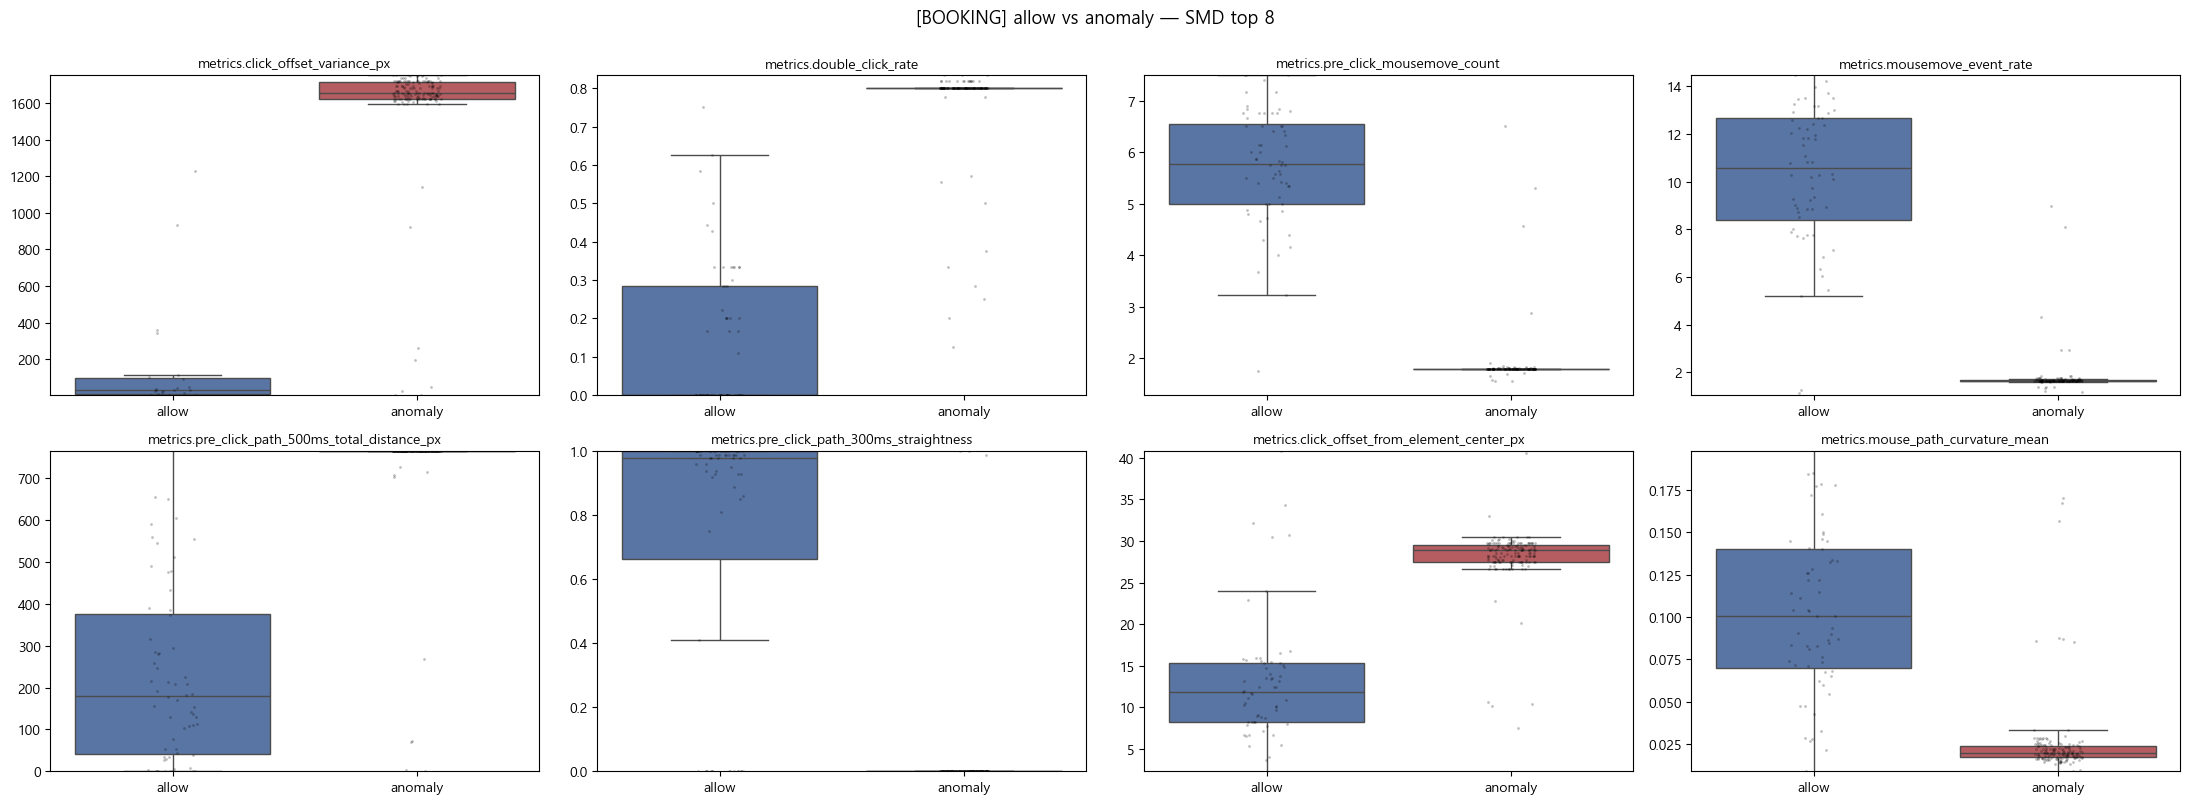

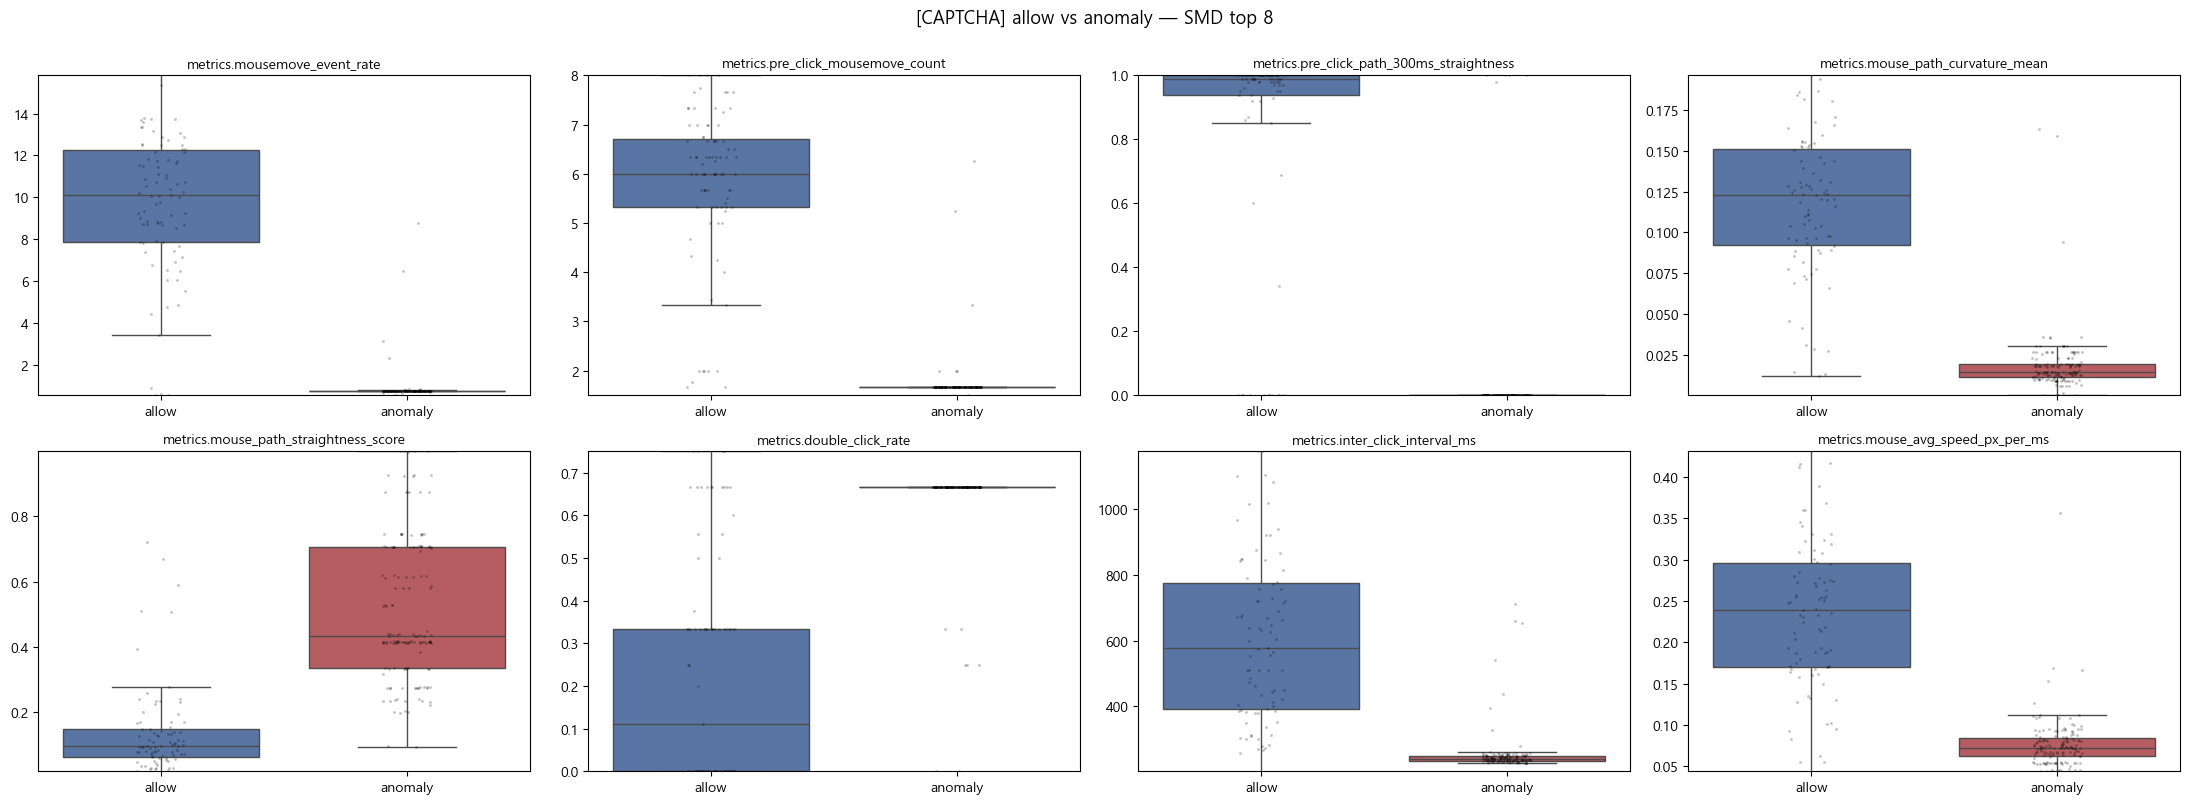

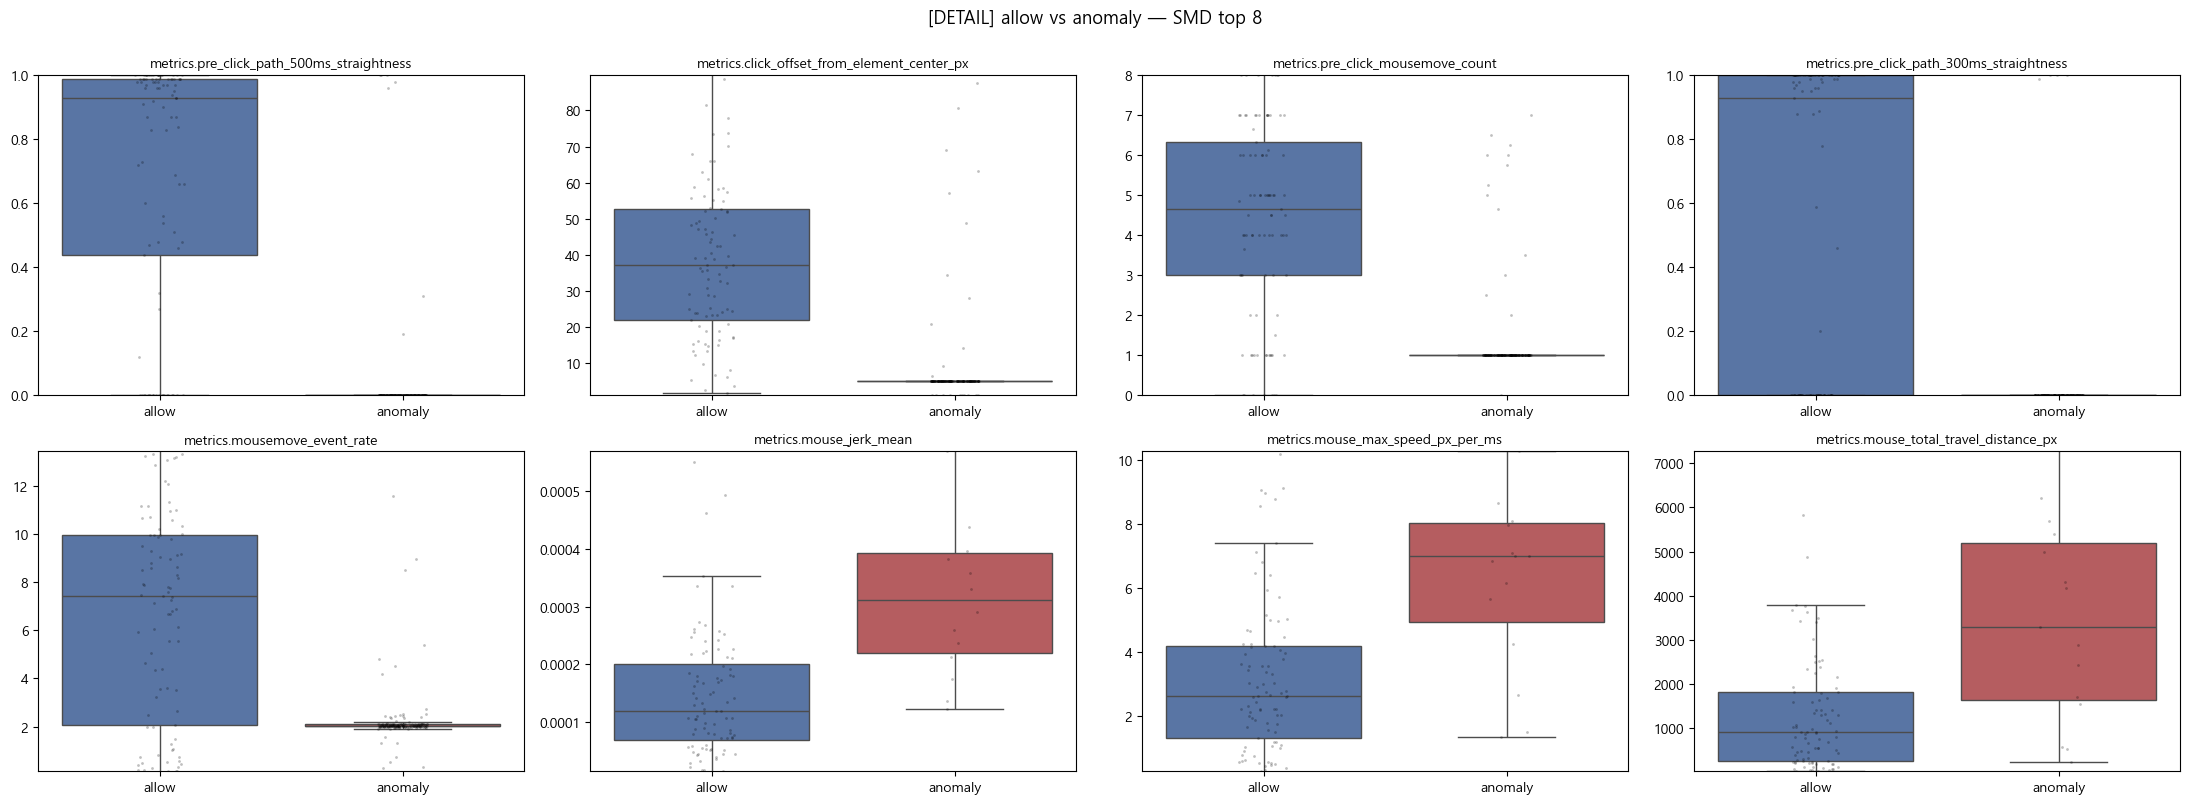

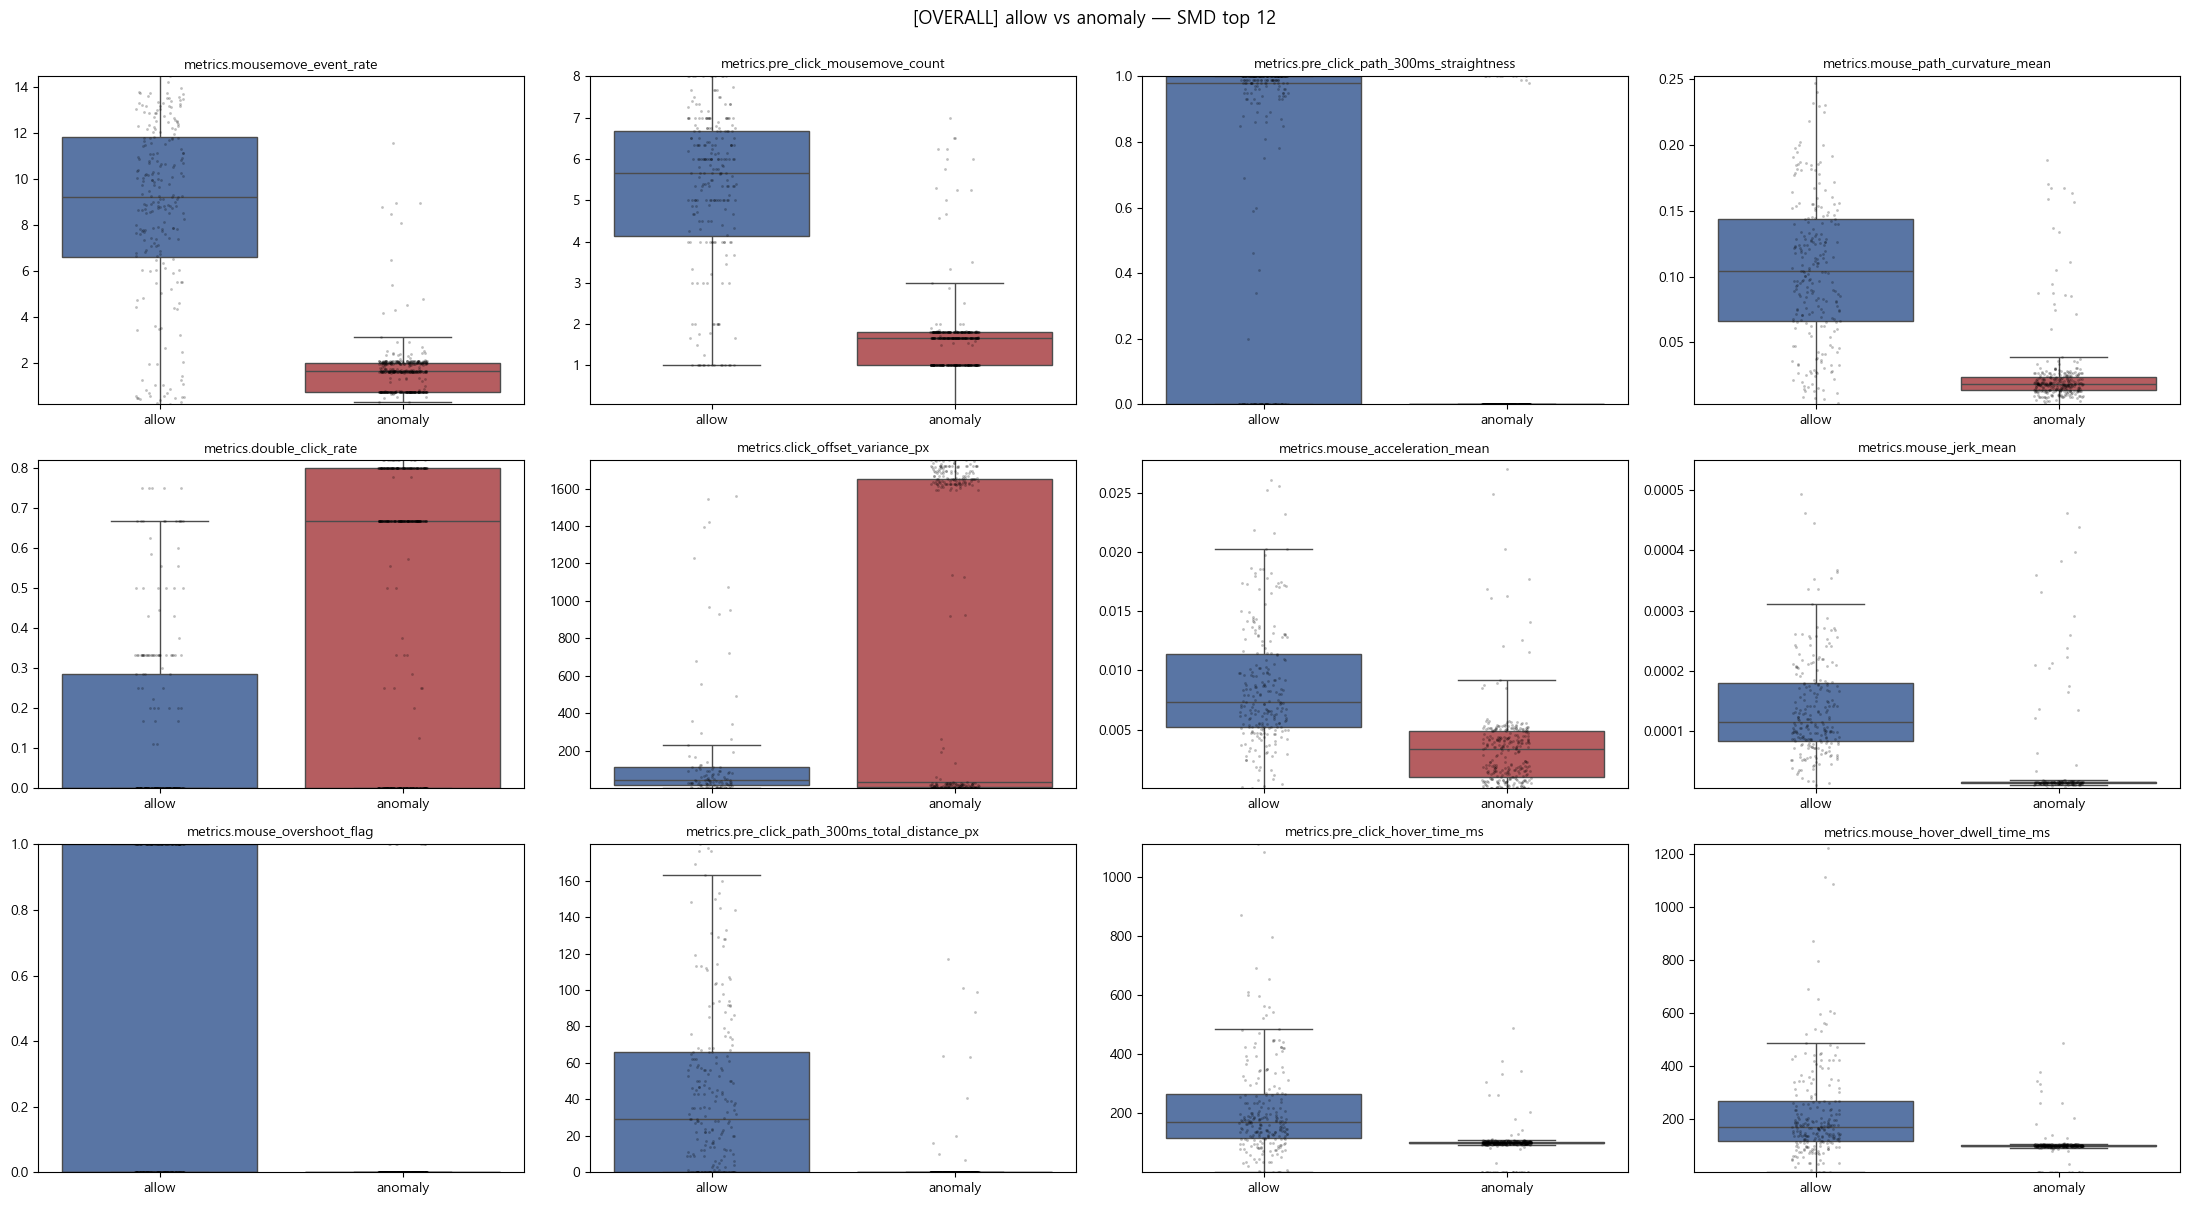

In [8]:
def _clip01(s):
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return None
    return lo, hi

def plot_box_grid(df, feats, group_col, title, n_cols=3):
    feats = list(feats)
    if not feats:
        print(f'[INFO] {title}: feature 가 없습니다 — skip')
        return
    n_rows = (len(feats) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.0 * n_rows))
    axes = np.atleast_2d(axes).reshape(n_rows, n_cols)
    for i, f in enumerate(feats):
        ax = axes[i // n_cols, i % n_cols]
        sub = df[[group_col, f]].dropna()
        if sub.empty:
            ax.set_title(f + ' (empty)'); ax.axis('off'); continue
        sns.boxplot(data=sub, x=group_col, y=f, ax=ax, showfliers=False,
                    palette={'allow': '#4C72B0', 'anomaly': '#C44E52'})
        sns.stripplot(data=sub, x=group_col, y=f, ax=ax,
                      size=2, color='black', alpha=0.25)
        clip = _clip01(sub[f])
        if clip is not None:
            ax.set_ylim(clip)
        ax.set_title(f, fontsize=10)
        ax.set_xlabel(''); ax.set_ylabel('')
    for j in range(len(feats), n_rows * n_cols):
        axes[j // n_cols, j % n_cols].axis('off')
    fig.suptitle(title, y=1.0, fontsize=13)
    plt.tight_layout(); plt.show()

# 6-1. type 별 SMD 상위 8 feature
for t in TYPES:
    top_feats = smd_by_type[t].dropna(subset=['SMD'])['feature'].head(8).tolist()
    plot_box_grid(df_eda[df_eda['type'] == t], top_feats, 'label_norm',
                  f'[{t}] allow vs anomaly — SMD top 8', n_cols=4)

# 6-2. 전체 SMD 상위 12 feature
top12 = smd_overall.dropna(subset=['SMD'])['feature'].head(12).tolist()
plot_box_grid(df_eda, top12, 'label_norm',
              '[OVERALL] allow vs anomaly — SMD top 12', n_cols=4)

## 7. PCA + Optional UMAP

전처리 pipeline: `SimpleImputer(median) → StandardScaler → PCA(2)`,  random_state=42
feature set = numeric − exclude − HIGH_RISK_MISSING_FEATURES

PC1 explained variance ratio = 0.2341
PC2 explained variance ratio = 0.1914
cumulative (PC1+PC2)         = 0.4255


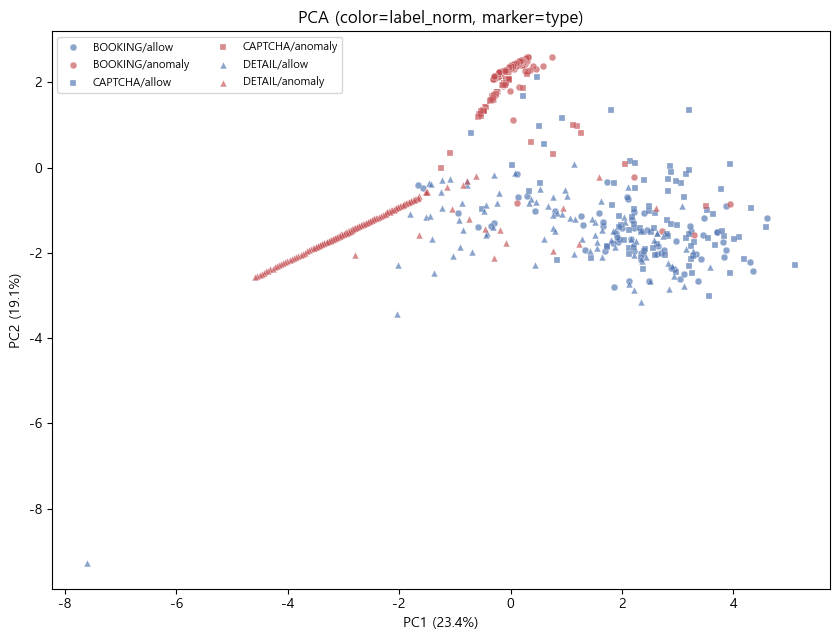

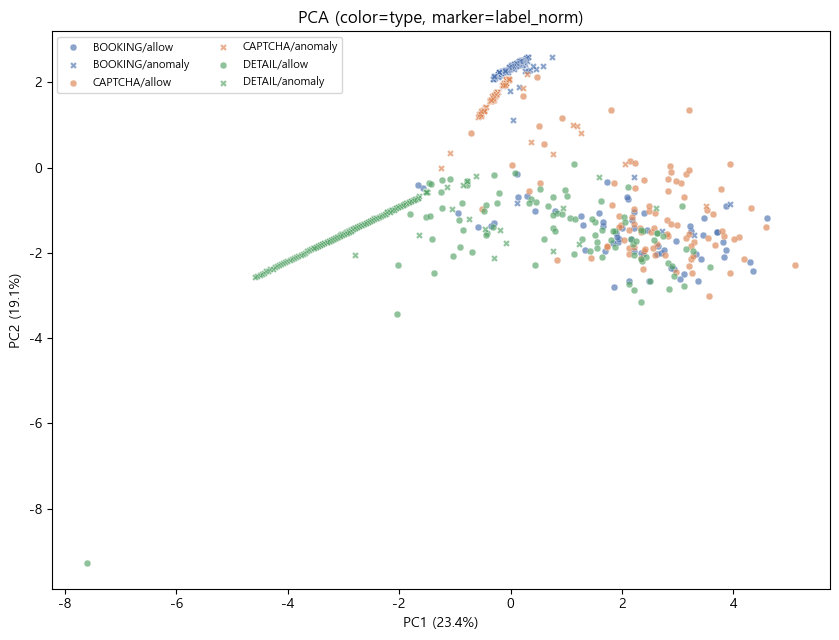

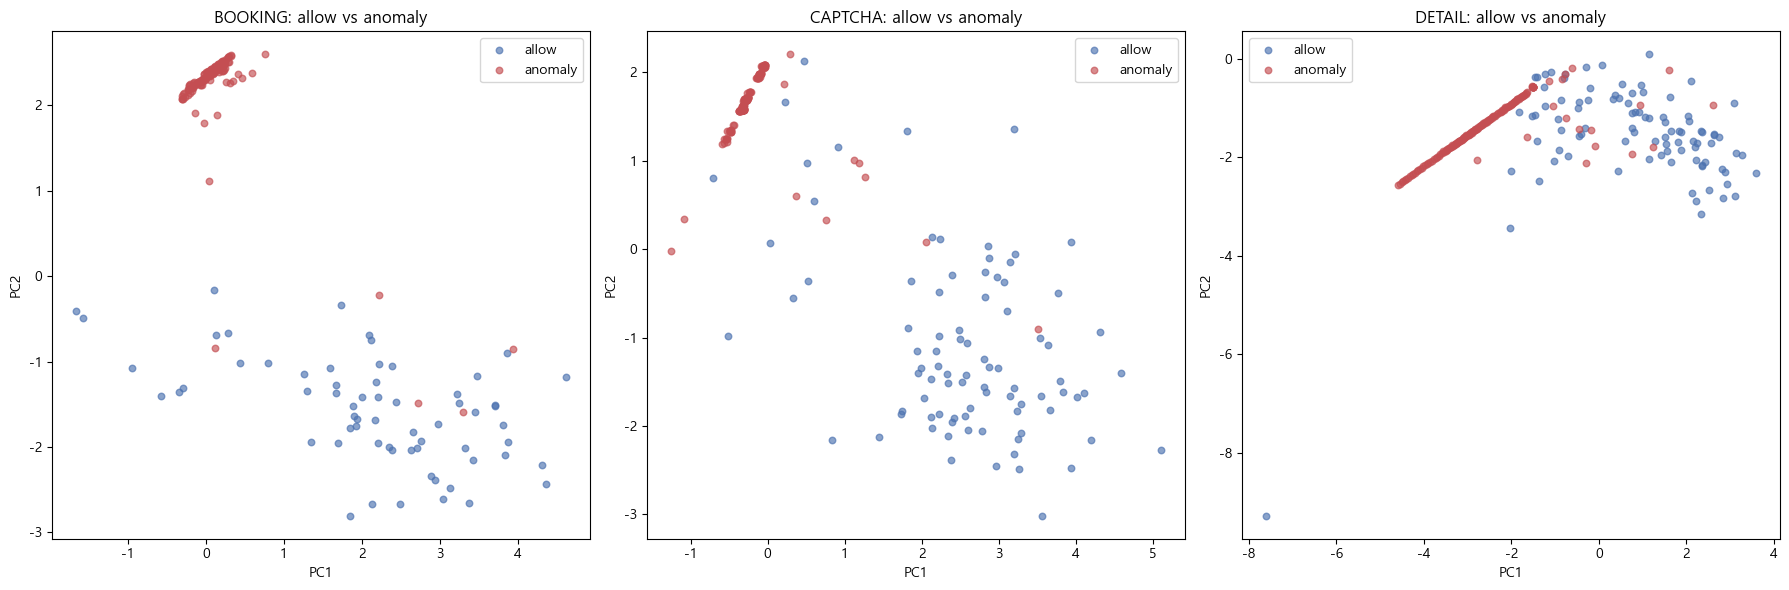

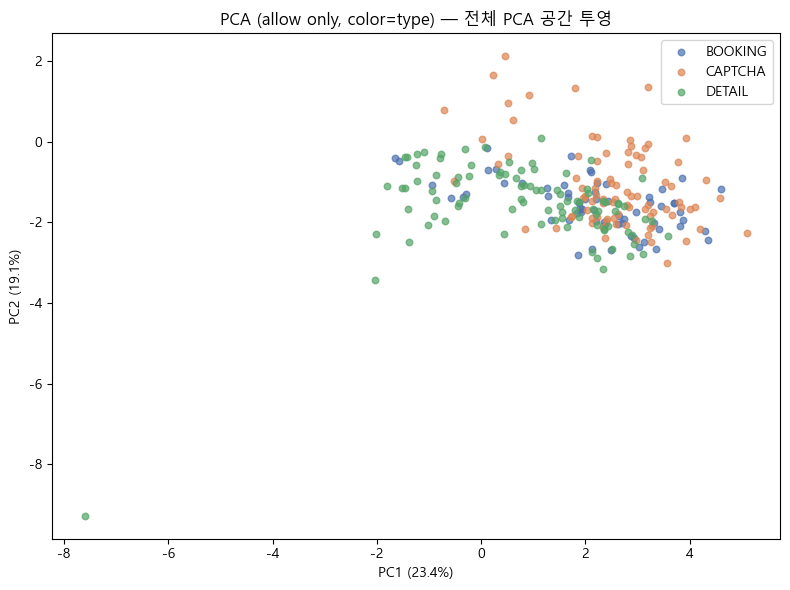

In [9]:
pca_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=RANDOM_STATE)),
])
X = df_eda[FEATURES_USED].values
proj = pca_pipe.fit_transform(X)
evr = pca_pipe.named_steps['pca'].explained_variance_ratio_
print(f'PC1 explained variance ratio = {evr[0]:.4f}')
print(f'PC2 explained variance ratio = {evr[1]:.4f}')
print(f'cumulative (PC1+PC2)         = {evr.sum():.4f}')

type_markers = {'BOOKING': 'o', 'CAPTCHA': 's', 'DETAIL': '^'}
label_colors = {'allow': '#4C72B0', 'anomaly': '#C44E52'}
type_colors = {'BOOKING': '#4C72B0', 'CAPTCHA': '#DD8452', 'DETAIL': '#55A467'}
label_markers = {'allow': 'o', 'anomaly': 'X'}
mask_allow = df_eda['label_norm'].values == 'allow'

# 1) color=label_norm, marker=type
fig, ax = plt.subplots(figsize=(8.5, 6.5))
for t, mk in type_markers.items():
    for lab, c in label_colors.items():
        m = (df_eda['type'] == t) & (df_eda['label_norm'] == lab)
        if m.any():
            ax.scatter(proj[m.values, 0], proj[m.values, 1],
                       marker=mk, color=c, s=24, alpha=0.65,
                       label=f'{t}/{lab}', edgecolor='white', linewidth=0.3)
ax.set_title('PCA (color=label_norm, marker=type)')
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

# 2) color=type, marker=label_norm
fig, ax = plt.subplots(figsize=(8.5, 6.5))
for t, c in type_colors.items():
    for lab, mk in label_markers.items():
        m = (df_eda['type'] == t) & (df_eda['label_norm'] == lab)
        if m.any():
            ax.scatter(proj[m.values, 0], proj[m.values, 1],
                       marker=mk, color=c, s=24, alpha=0.65,
                       label=f'{t}/{lab}', edgecolor='white', linewidth=0.3)
ax.set_title('PCA (color=type, marker=label_norm)')
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

# 3) type 별 subplot allow vs anomaly
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, t in zip(axes, TYPES):
    m_t = df_eda['type'].values == t
    for lab, c in label_colors.items():
        m = m_t & (df_eda['label_norm'].values == lab)
        if m.any():
            ax.scatter(proj[m, 0], proj[m, 1], color=c, s=22, alpha=0.65, label=lab)
    ax.set_title(f'{t}: allow vs anomaly')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend()
plt.tight_layout(); plt.show()

# 4) allow-only PCA color=type (전체 PCA 공간 투영)
fig, ax = plt.subplots(figsize=(8, 6))
for t, c in type_colors.items():
    m = mask_allow & (df_eda['type'].values == t)
    ax.scatter(proj[m, 0], proj[m, 1], color=c, s=22, alpha=0.7, label=t)
ax.set_title('PCA (allow only, color=type) — 전체 PCA 공간 투영')
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
ax.legend()
plt.tight_layout(); plt.show()

In [10]:
try:
    import umap  # type: ignore
    _scale_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc', StandardScaler()),
    ])
    X_scaled = _scale_pipe.fit_transform(X)
    um = umap.UMAP(n_components=2, random_state=RANDOM_STATE,
                   n_neighbors=15, min_dist=0.1)
    u_proj = um.fit_transform(X_scaled)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ax = axes[0]
    for t, mk in type_markers.items():
        for lab, c in label_colors.items():
            m = (df_eda['type'] == t) & (df_eda['label_norm'] == lab)
            if m.any():
                ax.scatter(u_proj[m.values, 0], u_proj[m.values, 1],
                           marker=mk, color=c, s=22, alpha=0.7,
                           label=f'{t}/{lab}', edgecolor='white', linewidth=0.3)
    ax.set_title('UMAP (color=label_norm, marker=type)')
    ax.legend(fontsize=8, ncol=2)
    ax = axes[1]
    for t, c in type_colors.items():
        m = mask_allow & (df_eda['type'].values == t)
        ax.scatter(u_proj[m, 0], u_proj[m, 1], color=c, s=22, alpha=0.7, label=t)
    ax.set_title('UMAP (allow only, color=type)')
    ax.legend()
    plt.tight_layout(); plt.show()
except Exception as e:
    print('[INFO] umap 사용 불가 — 건너뜀:', repr(e))

[INFO] umap 사용 불가 — 건너뜀: ModuleNotFoundError("No module named 'umap'")


## 8. Isolation Forest 전략 비교

| Strategy | Train | Threshold |
|---|---|---|
| A `pooled_global` | all allow | all allow validation 5th pct |
| B `pooled_type_threshold` | all allow | type 별 allow validation 5th pct |
| C `type_specific` | 각 type 의 allow | 각 type 의 allow validation 5th pct |

공통: `IsolationForest(random_state=42, n_estimators=200, contamination='auto')`,
decision_function 값이 클수록 정상, anomaly 판정 = `score < threshold`.
split: train_test_split(test_size=0.3, stratify=type, random_state=42).

In [11]:
IF_FEATURES = FEATURES_USED
N_MIN_TRAIN = 20
TH_PCT = 5
N_ESTIMATORS = 200

df_allow_all = df_eda[df_eda['label_norm'] == 'allow'].reset_index(drop=True)
df_anom_all = df_eda[df_eda['label_norm'] == 'anomaly'].reset_index(drop=True)

# allow split
allow_train_idx, allow_val_idx = train_test_split(
    df_allow_all.index, test_size=0.3, random_state=RANDOM_STATE,
    stratify=df_allow_all['type'],
)
df_allow_train = df_allow_all.loc[allow_train_idx].reset_index(drop=True)
df_allow_val = df_allow_all.loc[allow_val_idx].reset_index(drop=True)
print(f'allow train={len(df_allow_train)} | allow val={len(df_allow_val)} | anomaly={len(df_anom_all)}')

# pooled pre + model (Strategy A, also used by B)
pre_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc', StandardScaler()),
])
pre_pipe.fit(df_allow_train[IF_FEATURES].values)

def _xfm(df_in):
    return pre_pipe.transform(df_in[IF_FEATURES].values)

clf_A = IsolationForest(random_state=RANDOM_STATE,
                        n_estimators=N_ESTIMATORS,
                        contamination='auto')
clf_A.fit(_xfm(df_allow_train))
sc_val_A = clf_A.decision_function(_xfm(df_allow_val))
sc_anom_A = clf_A.decision_function(_xfm(df_anom_all))
th_A = float(np.percentile(sc_val_A, TH_PCT))

results = []
# A — overall row
results.append({
    'model_strategy': 'pooled_global', 'threshold_strategy': 'global_5pct',
    'type': 'ALL', 'n_allow': len(df_allow_val), 'n_anomaly': len(df_anom_all),
    'threshold': th_A,
    'allow_FPR': float(np.mean(sc_val_A < th_A)),
    'anomaly_TPR': float(np.mean(sc_anom_A < th_A)),
    'score_gap_mean': float(np.mean(sc_val_A) - np.mean(sc_anom_A)),
    'score_gap_median': float(np.median(sc_val_A) - np.median(sc_anom_A)),
})
# A — per-type breakdown with single global threshold
for t in TYPES:
    m_v = df_allow_val['type'].values == t
    m_a = df_anom_all['type'].values == t
    if m_v.sum() == 0 or m_a.sum() == 0:
        print(f'[WARN] pooled_global: type={t} 데이터 없음 — skip')
        continue
    s_v = sc_val_A[m_v]; s_a = sc_anom_A[m_a]
    results.append({
        'model_strategy': 'pooled_global', 'threshold_strategy': 'global_5pct',
        'type': t, 'n_allow': int(m_v.sum()), 'n_anomaly': int(m_a.sum()),
        'threshold': th_A,
        'allow_FPR': float(np.mean(s_v < th_A)),
        'anomaly_TPR': float(np.mean(s_a < th_A)),
        'score_gap_mean': float(np.mean(s_v) - np.mean(s_a)),
        'score_gap_median': float(np.median(s_v) - np.median(s_a)),
    })

# B — pooled_type_threshold (same clf_A, per-type threshold)
type_thresholds_B = {}
for t in TYPES:
    m_v = df_allow_val['type'].values == t
    if m_v.sum() < 5:
        print(f'[WARN] pooled_type_threshold: type={t} val 수 {m_v.sum()} < 5 — skip')
        continue
    type_thresholds_B[t] = float(np.percentile(sc_val_A[m_v], TH_PCT))
for t in TYPES:
    if t not in type_thresholds_B:
        continue
    th = type_thresholds_B[t]
    m_v = df_allow_val['type'].values == t
    m_a = df_anom_all['type'].values == t
    s_v = sc_val_A[m_v]; s_a = sc_anom_A[m_a]
    results.append({
        'model_strategy': 'pooled_global', 'threshold_strategy': 'per_type_5pct',
        'type': t, 'n_allow': int(m_v.sum()), 'n_anomaly': int(m_a.sum()),
        'threshold': th,
        'allow_FPR': float(np.mean(s_v < th)),
        'anomaly_TPR': float(np.mean(s_a < th)) if len(s_a) else np.nan,
        'score_gap_mean': float(np.mean(s_v) - np.mean(s_a)),
        'score_gap_median': float(np.median(s_v) - np.median(s_a)),
    })

# C — type_specific
type_thresholds_C = {}
sc_records_C = {}
for t in TYPES:
    sub_train = df_allow_train[df_allow_train['type'] == t]
    sub_val = df_allow_val[df_allow_val['type'] == t]
    sub_anom = df_anom_all[df_anom_all['type'] == t]
    if len(sub_train) < N_MIN_TRAIN or len(sub_val) < 5 or len(sub_anom) == 0:
        print(f'[WARN] type_specific: type={t} train={len(sub_train)} val={len(sub_val)} anom={len(sub_anom)} — skip')
        continue
    pre_t = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc', StandardScaler()),
    ])
    Xt = pre_t.fit_transform(sub_train[IF_FEATURES].values)
    clf_t = IsolationForest(random_state=RANDOM_STATE,
                            n_estimators=N_ESTIMATORS,
                            contamination='auto')
    clf_t.fit(Xt)
    s_v = clf_t.decision_function(pre_t.transform(sub_val[IF_FEATURES].values))
    s_a = clf_t.decision_function(pre_t.transform(sub_anom[IF_FEATURES].values))
    th_t = float(np.percentile(s_v, TH_PCT))
    type_thresholds_C[t] = th_t
    sc_records_C[t] = (s_v, s_a)
    results.append({
        'model_strategy': 'type_specific', 'threshold_strategy': 'per_type_5pct',
        'type': t, 'n_allow': int(len(sub_val)), 'n_anomaly': int(len(sub_anom)),
        'threshold': th_t,
        'allow_FPR': float(np.mean(s_v < th_t)),
        'anomaly_TPR': float(np.mean(s_a < th_t)),
        'score_gap_mean': float(np.mean(s_v) - np.mean(s_a)),
        'score_gap_median': float(np.median(s_v) - np.median(s_a)),
    })

res_df = pd.DataFrame(results)
print('\n=== Strategy 성능 비교 ===')
print(res_df.to_string(index=False))

# macro / weighted avg (per-type rows only)
per_type_rows = res_df[res_df['type'].isin(TYPES)].copy()
agg_rows = []
for (ms, ts), grp in per_type_rows.groupby(['model_strategy', 'threshold_strategy']):
    macro_tpr = float(grp['anomaly_TPR'].mean())
    macro_fpr = float(grp['allow_FPR'].mean())
    w_a = grp['n_anomaly'].astype(float)
    w_l = grp['n_allow'].astype(float)
    weighted_tpr = float((grp['anomaly_TPR'] * w_a).sum() / w_a.sum()) if w_a.sum() > 0 else np.nan
    weighted_fpr = float((grp['allow_FPR'] * w_l).sum() / w_l.sum()) if w_l.sum() > 0 else np.nan
    agg_rows.append({
        'model_strategy': ms, 'threshold_strategy': ts,
        'macro_allow_FPR': macro_fpr, 'macro_anomaly_TPR': macro_tpr,
        'weighted_allow_FPR': weighted_fpr, 'weighted_anomaly_TPR': weighted_tpr,
    })
agg_df = pd.DataFrame(agg_rows)
print('\n=== Strategy macro / weighted avg by type ===')
print(agg_df.to_string(index=False))

allow train=170 | allow val=74 | anomaly=463

=== Strategy 성능 비교 ===
model_strategy threshold_strategy    type  n_allow  n_anomaly  threshold  allow_FPR  anomaly_TPR  score_gap_mean  score_gap_median
 pooled_global        global_5pct     ALL       74        463  -0.016179   0.054054     0.602592        0.089719          0.099117
 pooled_global        global_5pct BOOKING       20        148  -0.016179   0.100000     0.959459        0.133093          0.145815
 pooled_global        global_5pct CAPTCHA       26        151  -0.016179   0.076923     0.245033        0.051389          0.037822
 pooled_global        global_5pct  DETAIL       28        164  -0.016179   0.000000     0.609756        0.086255          0.106545
 pooled_global      per_type_5pct BOOKING       20        148  -0.026729   0.050000     0.952703        0.133093          0.145815
 pooled_global      per_type_5pct CAPTCHA       26        151  -0.016447   0.076923     0.245033        0.051389          0.037822
 pooled_global

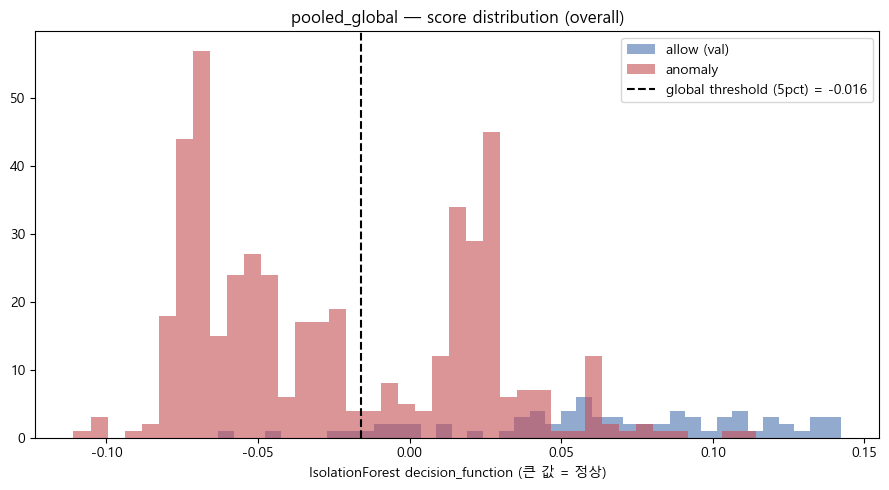

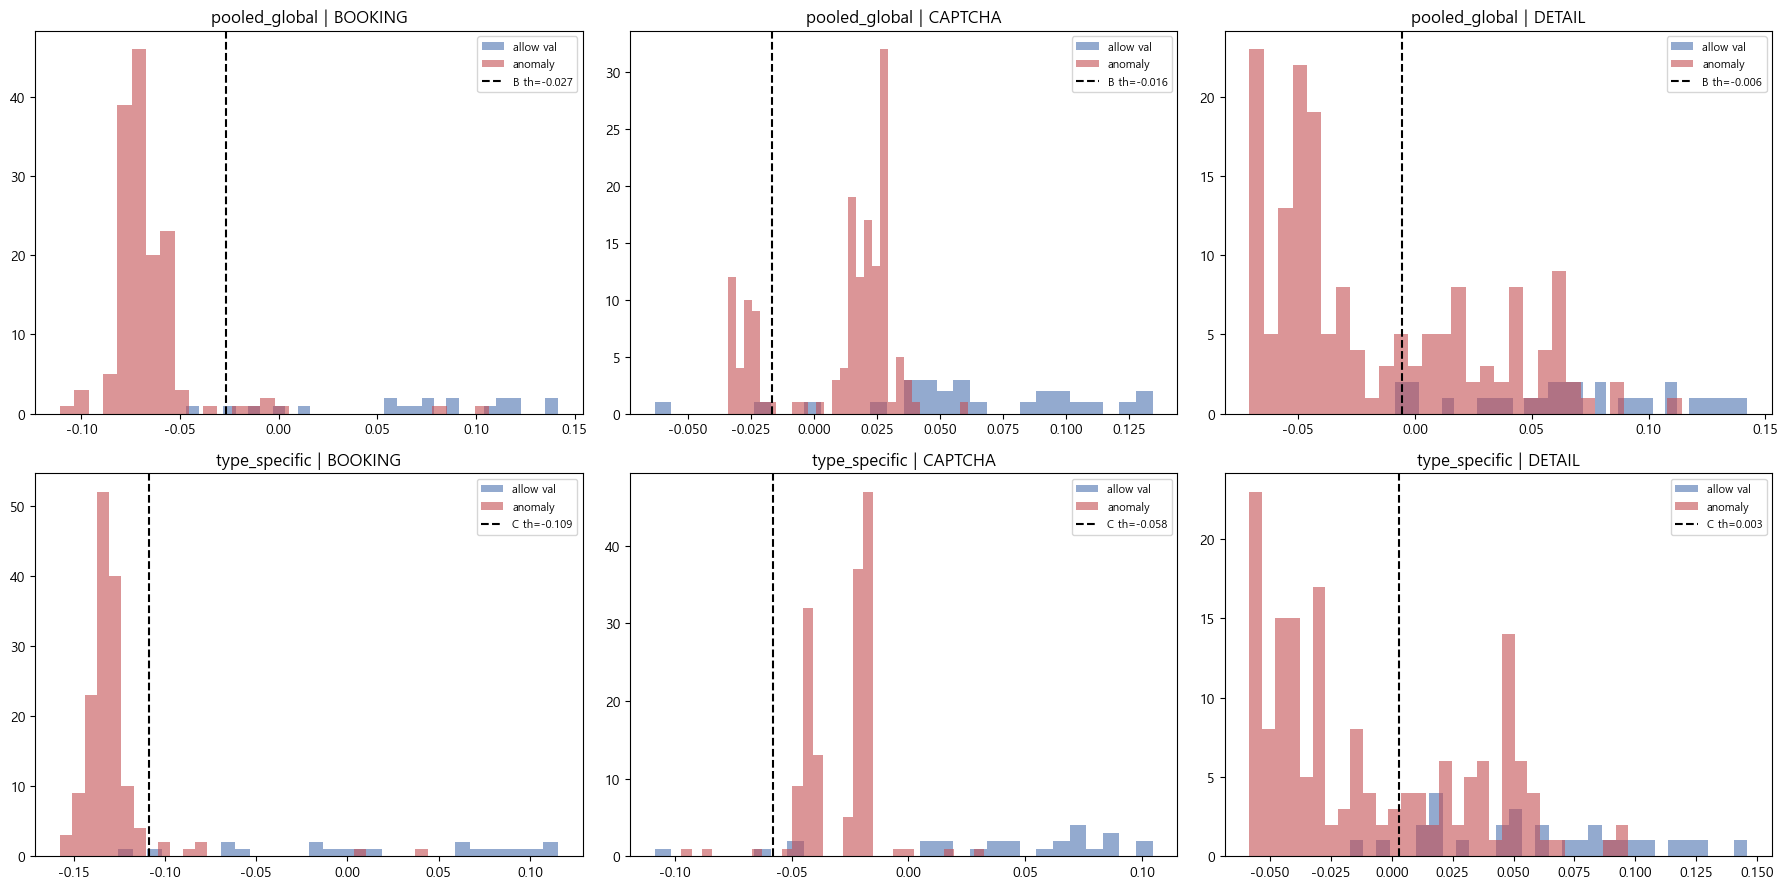

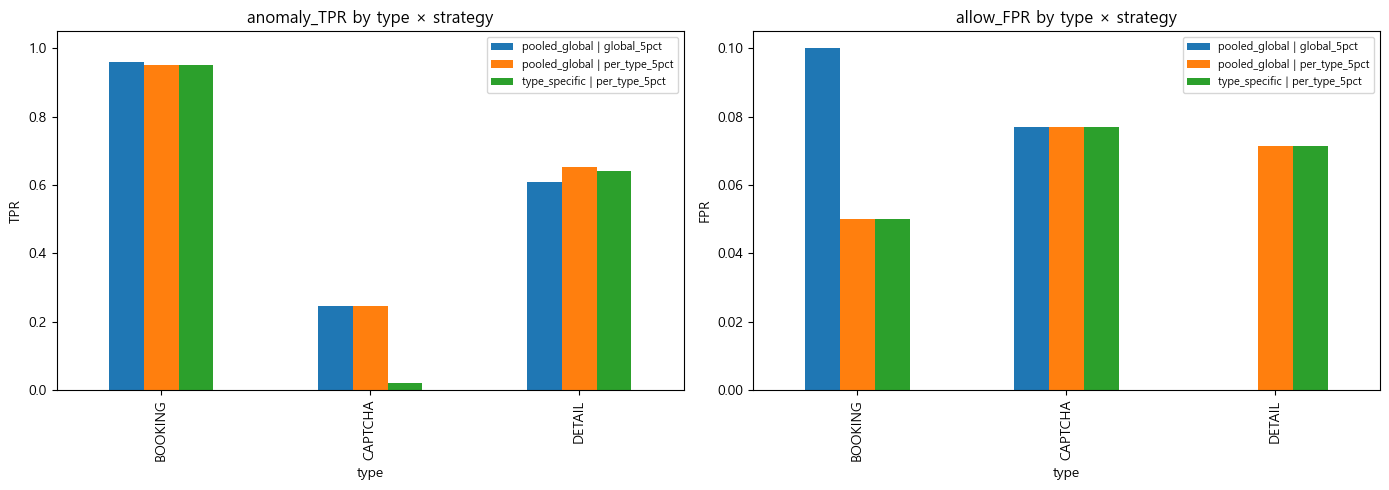

In [12]:
# pooled_global overall score distribution
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(sc_val_A, bins=40, alpha=0.6, color='#4C72B0', label='allow (val)')
ax.hist(sc_anom_A, bins=40, alpha=0.6, color='#C44E52', label='anomaly')
ax.axvline(th_A, color='black', linestyle='--', label=f'global threshold (5pct) = {th_A:.3f}')
ax.set_title('pooled_global — score distribution (overall)')
ax.set_xlabel('IsolationForest decision_function (큰 값 = 정상)')
ax.legend()
plt.tight_layout(); plt.show()

# type별 score distribution: row0 = pooled_global, row1 = type_specific
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for col, t in enumerate(TYPES):
    ax = axes[0, col]
    m_v = df_allow_val['type'].values == t
    m_a = df_anom_all['type'].values == t
    s_v = sc_val_A[m_v]; s_a = sc_anom_A[m_a]
    if len(s_v):
        ax.hist(s_v, bins=30, alpha=0.6, color='#4C72B0', label='allow val')
    if len(s_a):
        ax.hist(s_a, bins=30, alpha=0.6, color='#C44E52', label='anomaly')
    th_B = type_thresholds_B.get(t)
    if th_B is not None:
        ax.axvline(th_B, color='black', linestyle='--', label=f'B th={th_B:.3f}')
    ax.set_title(f'pooled_global | {t}')
    ax.legend(fontsize=8)

    ax = axes[1, col]
    if t in sc_records_C:
        s_v_c, s_a_c = sc_records_C[t]
        ax.hist(s_v_c, bins=30, alpha=0.6, color='#4C72B0', label='allow val')
        ax.hist(s_a_c, bins=30, alpha=0.6, color='#C44E52', label='anomaly')
        ax.axvline(type_thresholds_C[t], color='black', linestyle='--',
                   label=f'C th={type_thresholds_C[t]:.3f}')
        ax.set_title(f'type_specific | {t}')
        ax.legend(fontsize=8)
    else:
        ax.set_title(f'type_specific | {t} (skipped)')
        ax.axis('off')
plt.tight_layout(); plt.show()

# strategy 비교 barplot (per-type)
per_type_rows = per_type_rows.assign(
    strategy=per_type_rows['model_strategy'] + ' | ' + per_type_rows['threshold_strategy']
)
piv_tpr = per_type_rows.pivot_table(index='type', columns='strategy', values='anomaly_TPR')
piv_fpr = per_type_rows.pivot_table(index='type', columns='strategy', values='allow_FPR')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
piv_tpr.plot(kind='bar', ax=axes[0])
axes[0].set_title('anomaly_TPR by type × strategy')
axes[0].set_ylabel('TPR'); axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)
piv_fpr.plot(kind='bar', ax=axes[1])
axes[1].set_title('allow_FPR by type × strategy')
axes[1].set_ylabel('FPR')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9. Final Auto Summary

In [13]:
lines = []
lines.append('=' * 72)
lines.append('EDA Auto Summary — data_0514_1800_v2 (allow vs anomaly × type)')
lines.append('=' * 72)

# 1) sample counts
ct = pd.crosstab(df_eda['label_norm'], df_eda['type'])
lines.append('\n[1] Sample counts (label_norm × type):')
for t in TYPES:
    n_allow = int(ct.loc['allow', t]) if (t in ct.columns and 'allow' in ct.index) else 0
    n_anom = int(ct.loc['anomaly', t]) if (t in ct.columns and 'anomaly' in ct.index) else 0
    flag = ''
    if n_anom < 30 or n_allow < 30:
        flag = '  <- WARN: sample 부족'
    lines.append(f'  {t:8s}: allow={n_allow:4d}, anomaly={n_anom:4d}{flag}')

# 2) high missing
lines.append(f'\n[2] High-missing features (제외 권장, n={len(HIGH_RISK_MISSING_FEATURES)}):')
if HIGH_RISK_MISSING_FEATURES:
    for f in HIGH_RISK_MISSING_FEATURES:
        lines.append(f'  - {f}  (overall={miss_overall[f]:.2f}, group_max={group_max[f]:.2f})')
else:
    lines.append('  (없음)')

# 3) allow-only type 차이 top 10
lines.append('\n[3] Allow-only type 차이 top 10 (max |SMD|):')
top_a = allow_type_smd.dropna(subset=['max_abs_SMD']).head(10)
for _, r in top_a.iterrows():
    lines.append(f'  - {r["feature"]:50s} |SMD|={r["max_abs_SMD"]:.3f} ({r["pair"]})')
if top_a.empty:
    lines.append('  (계산 불가)')

# 4) allow vs anomaly top 10
lines.append('\n[4] Allow vs anomaly 차이 top 10 (|SMD|):')
top_o = smd_overall.dropna(subset=['SMD']).head(10)
for _, r in top_o.iterrows():
    lines.append(f'  - {r["feature"]:50s} |SMD|={r["abs_SMD"]:.3f}  (allow={r["mean_allow"]:.3f}, anom={r["mean_anomaly"]:.3f})')

# 5) type별 강도
lines.append('\n[5] Type별 allow vs anomaly 강도 (top-5 평균 |SMD|):')
type_strength = {}
for t in TYPES:
    top5 = smd_by_type[t].dropna(subset=['abs_SMD']).head(5)['abs_SMD'].mean()
    type_strength[t] = top5
    if not np.isfinite(top5):
        lines.append(f'  {t:8s}: 데이터 부족')
    else:
        tag = '강함' if top5 >= 0.8 else ('중간' if top5 >= 0.4 else '약함')
        lines.append(f'  {t:8s}: top5 mean |SMD| = {top5:.3f}  ->  {tag}')

# 6) IF 전략 추천
def _macro(model_s, thresh_s):
    sub = res_df[(res_df['model_strategy'] == model_s) &
                 (res_df['threshold_strategy'] == thresh_s) &
                 (res_df['type'].isin(TYPES))]
    if sub.empty:
        return None, None
    return float(sub['anomaly_TPR'].mean()), float(sub['allow_FPR'].mean())

tpr_A, fpr_A = _macro('pooled_global', 'global_5pct')
tpr_B, fpr_B = _macro('pooled_global', 'per_type_5pct')
tpr_C, fpr_C = _macro('type_specific', 'per_type_5pct')

lines.append('\n[6] IsolationForest 전략 macro TPR / FPR (per-type 평균):')
lines.append(f'  A pooled_global      : TPR={tpr_A:.3f} / FPR={fpr_A:.3f}' if tpr_A is not None else '  A pooled_global      : (n/a)')
lines.append(f'  B pooled+type_thresh : TPR={tpr_B:.3f} / FPR={fpr_B:.3f}' if tpr_B is not None else '  B pooled+type_thresh : (n/a)')
lines.append(f'  C type_specific      : TPR={tpr_C:.3f} / FPR={fpr_C:.3f}' if tpr_C is not None else '  C type_specific      : (n/a)')

recos = []
if (tpr_A is not None and tpr_C is not None
        and tpr_C > tpr_A + 0.02 and abs(fpr_C - fpr_A) < 0.05):
    recos.append('type_specific 추천: type별 IF 모델이 anomaly 탐지력이 더 높고 FPR 은 유사.')
if (tpr_B is not None and tpr_C is not None
        and abs(tpr_B - tpr_C) < 0.03):
    recos.append('pooled + per-type threshold 추천 가능: type별 threshold 만으로도 type_specific 와 유사 성능.')
if all((v is not None and v < 0.5) for v in (tpr_A, tpr_B, tpr_C)):
    recos.append('세 전략 모두 TPR < 0.5 — IF 단독 한계 가능. supervised 또는 추가 feature 검토 필요.')
type_tpr_C_series = res_df[(res_df['model_strategy'] == 'type_specific')
                            & (res_df['type'].isin(TYPES))]['anomaly_TPR']
if not type_tpr_C_series.empty and (type_tpr_C_series.max() - type_tpr_C_series.min()) > 0.3:
    recos.append('type 간 TPR 편차가 큼 — 약한 type 의 feature / threshold 재검토 필요.')
if not recos:
    recos.append('세 전략 성능이 비슷 — 운영 단순성 측면에서 pooled_global 도 후보.')
for r in recos:
    lines.append(f'  -> {r}')

lines.append('\n[7] Caveat: 본 결론은 dev EDA 기준이며 validation / test 데이터로 재확인 필요.')
lines.append('          random_state=42 고정. high-missing feature 는 제외된 상태.')
lines.append('=' * 72)

print('\n'.join(lines))

EDA Auto Summary — data_0514_1800_v2 (allow vs anomaly × type)

[1] Sample counts (label_norm × type):
  BOOKING : allow=  64, anomaly= 148
  CAPTCHA : allow=  87, anomaly= 151
  DETAIL  : allow=  93, anomaly= 164

[2] High-missing features (제외 권장, n=13):
  - metrics.mouse_jerk_mean  (overall=0.43, group_max=0.95)
  - metrics.inter_click_interval_ms  (overall=0.33, group_max=0.95)
  - metrics.mouse_acceleration_mean  (overall=0.22, group_max=0.91)
  - metrics.mouse_speed_change_mean  (overall=0.22, group_max=0.91)
  - metrics.click_offset_variance_px  (overall=0.42, group_max=0.99)
  - metrics.mouse_avg_speed_px_per_ms  (overall=0.22, group_max=0.91)
  - metrics.mouse_hover_dwell_time_ms  (overall=0.22, group_max=0.91)
  - metrics.mouse_max_speed_px_per_ms  (overall=0.22, group_max=0.91)
  - metrics.mouse_path_curvature_mean  (overall=0.22, group_max=0.91)
  - metrics.mouse_path_straightness_score  (overall=0.22, group_max=0.91)
  - metrics.edge_or_fixed_point_visit_rate  (overall=0.22